In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from matplotlib.colors import ListedColormap

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import h5py
from scipy import sparse, linalg
from scipy.optimize import curve_fit, root
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import matplotlib as mpl

# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

# Recreate Results plot

In [26]:
labels = [r'$\bar{v} \bar{u}_y$', r'$\bar{w}\bar{u}_z$',
        r'$\nu \bar{u}_{yy}$', r'$\nu \bar{u}_{zz}$',
        r'$\overline{({u^\prime v^\prime})}_y$', r'$\overline{(u^\prime w^\prime)}_z$']

In [13]:
data = loadmat('../AR_1_180(HiFi)/duct180.mat',squeeze_me=True, struct_as_record=False)['duct180']

x = data.xx
y = data.yy

xx,yy = np.meshgrid(x,y)

nc = 7

x_quad = xx[0:97, 0:97]
y_quad = yy[0:97, 0:97]

In [18]:
# load pre computed cluster_idx labels
cluster_idx = np.load("cluster_idx.npy")
features = np.load("features.npy")

nfeatures = features.shape[1]

In [19]:
def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
            print(active_terms)
        else: print('None')

    return spca_model

In [20]:
cluster_err = []
alphas = 1e-1*np.array([0.001,0.0025,0.005,0.01,0.0125,0.015,0.0175,0.02,0.0225,0.025,0.0325,0.0375,0.048,0.05,0.0625,0.075,0.08,0.0875,0.1,0.11,0.12,0.13,0.14,0.15,0.175,0.2,0.225,0.25,0.3,0.35,0.4,0.45,0.5,0.625,0.75,0.8,0.85,0.875,1,1.5,2.0,3.0,4.0,5.0,7.0,10.0,12.0,15.0,20.0,1000])

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx, i))

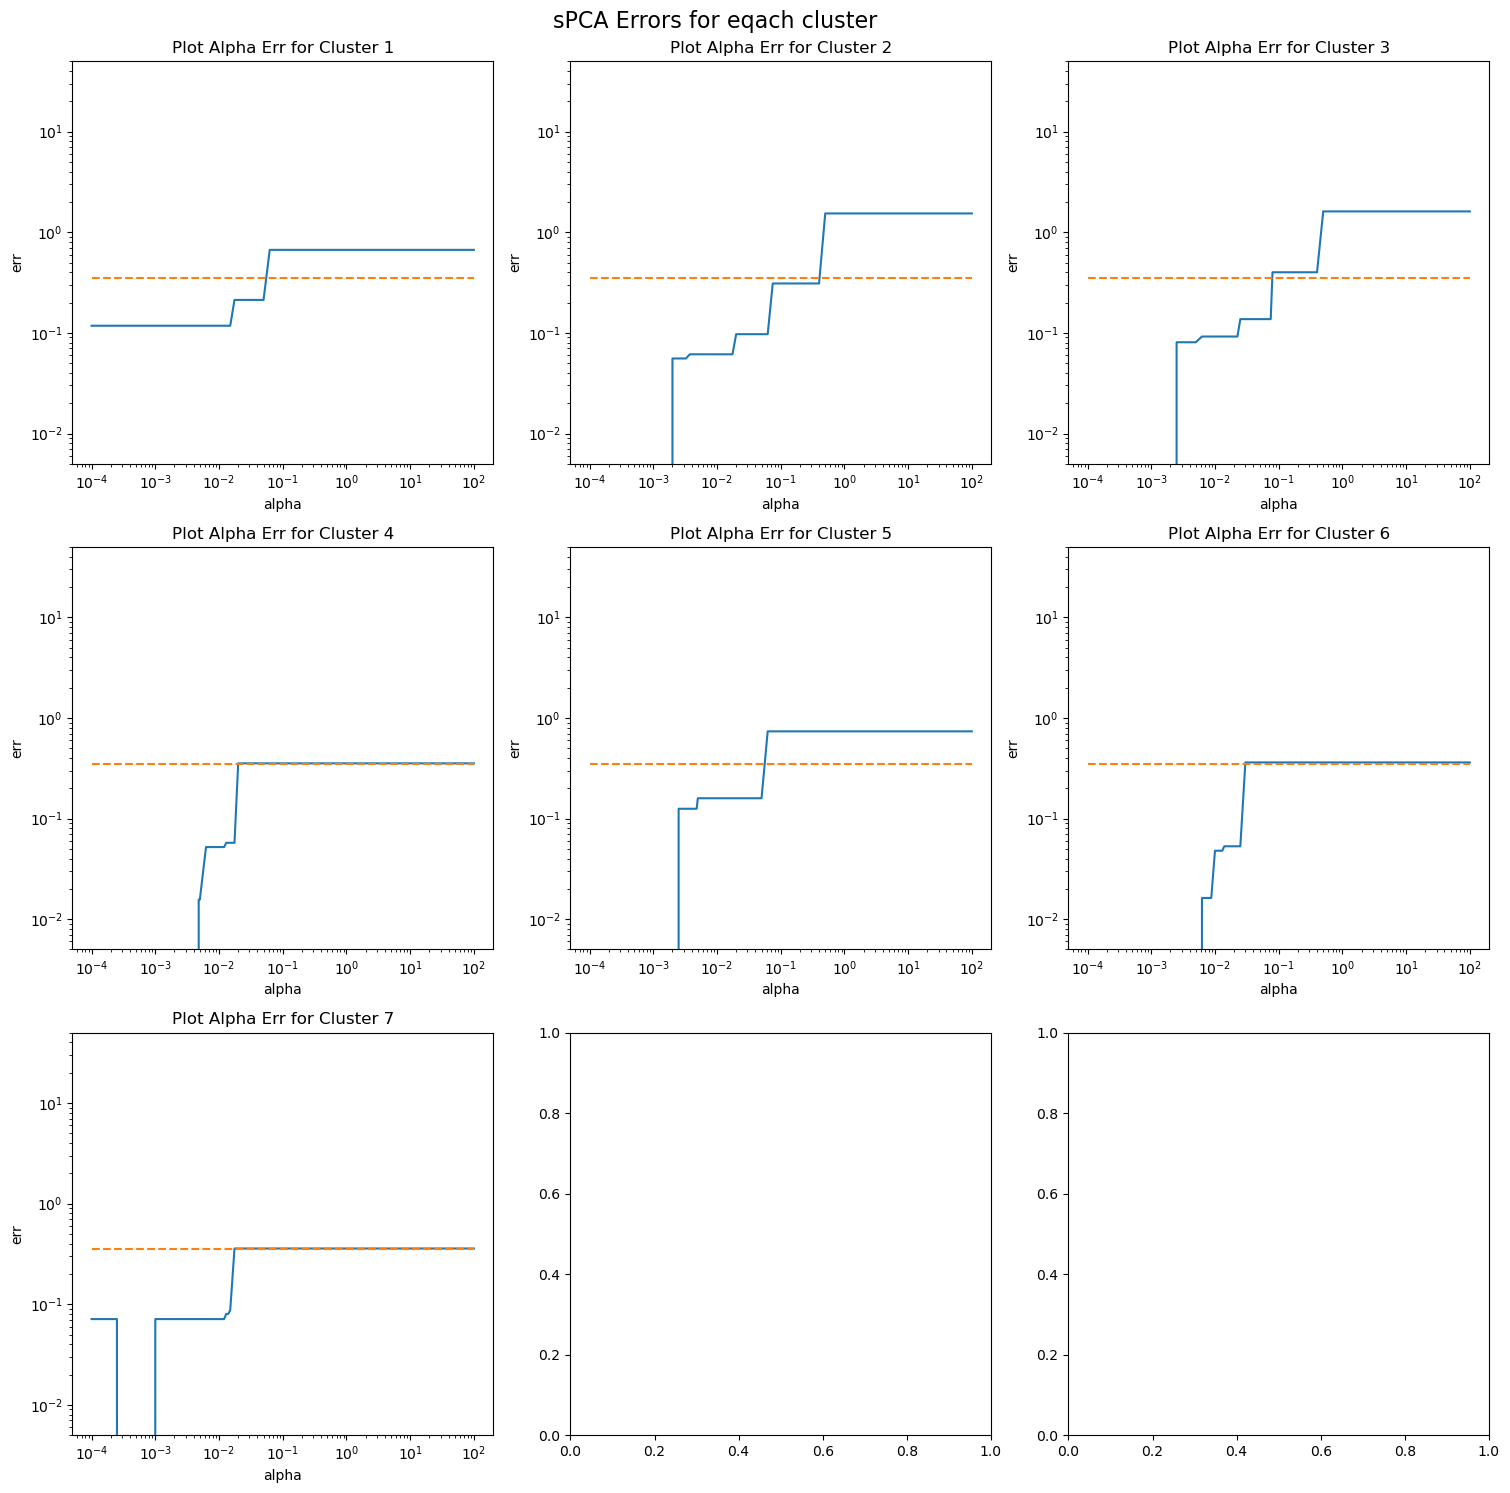

In [21]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    axes[i].loglog(alphas, 0.35 * np.ones_like(np.array(alphas)), linestyle='--')
    # if i == 2:
    #     axes[i].set_xlim(0.0625,0.0875)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')
    axes[i].set_ylim(5e-3,50)

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [22]:
# err_threshold = 28 maximum I can truncate before I loose viscous effect in the part over the the 
err_threshold = 0.35

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

print(alpha_opt)
optimal_alphas = alpha_opt

[0.05, 0.4, 0.07500000000000001, 0.017499999999999998, 0.05, 0.025, 0.015]


In [23]:
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten())

[0 1 3 5]
[2 4]
[1 3 5]
[1 3 5]
[0 1 2 4]
[0 2 4]
[1 4 5]


In [24]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten()])

# Make the colors nice, swap green & orange, than green & brown
model_index = np.where(model_index==1, 0, np.where(model_index == 0, 1, model_index))
balance_model_row_save = balance_models[1].copy()
balance_models[1] = balance_models[0]
balance_models[0] = balance_model_row_save

model_index = np.where(model_index==2, 5, np.where(model_index == 5, 2, model_index))
balance_model_row_save = balance_models[2].copy()
balance_models[2] = balance_models[5]
balance_models[5] = balance_model_row_save

model_index = np.where(model_index==2, 1, np.where(model_index == 1, 2, model_index))
balance_model_row_save = balance_models[2].copy()
balance_models[2] = balance_models[1]
balance_models[1] = balance_model_row_save

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten()])

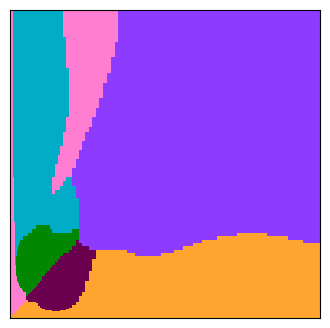

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize = (4.0,4.0))
plt.pcolormesh(x_quad,y_quad, (balance_idx+1).reshape(x_quad.shape), cmap = cm_balance_models, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(f'RANSDuct_sPCA_ClusterDomain,nc{nc}', transparent=True,dpi=720)
plt.show()
plt.clf()

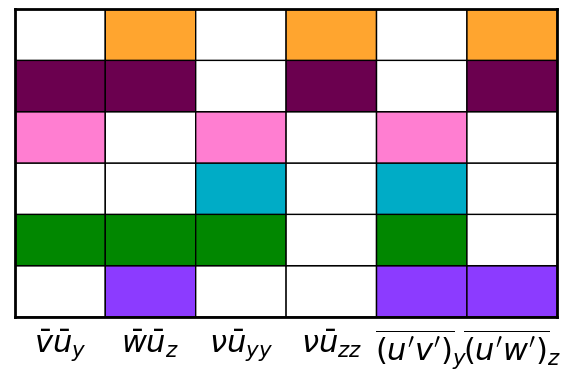

<Figure size 640x480 with 0 Axes>

In [27]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

# NOTE We're skipping the deleting of unidentified terms because I need to count terms correctly identified as 0 in my quantitative metric
# plot spca_model matrix
# Delete zero terms
# grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
# gridmap = np.delete(gridmap, grid_mask, axis=1)
# grid_labels = np.delete(labels, grid_mask)

grid_labels = labels

plt.figure(figsize=(7, 4))
plt.pcolor(gridmap, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels, fontsize=22)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.savefig(f'DuctRANS_sPCA_Matrix_Model', bbox_inches='tight',transparent=True, dpi=480)
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

# Code to fully recreate clusters below:

# Z-momentum equation

(Note: according to the data, *z* is the streamwise direction, whereas *x* is considered streamwiase in the paper)

$$(\bar{U} \partial_x \bar{W}) + (\bar{V} \partial_y \bar{W}) = -\partial_z \bar{p}' + \nu(\partial_{xx} \bar{W} + \partial_{yy} \bar{W}) - (\partial_x(\bar{uw}) + \partial_y (\bar{vw}))$$

In [ ]:
# Import Vinuesa derivative operator that was specifically given as 6th order accurate for the duct
from RicardoHelper import diff6

In [4]:
def Dx(f, x):
    ny,nx = f.shape
    dfdx = np.ndarray(f.shape)
    for i in range(ny):
        dfdx[i,:] = diff6(f[i,:], x)

    return dfdx

In [5]:
def Dy(f, y):
    ny,nx = f.shape
    dfdx = np.ndarray(f.shape)
    for i in range(nx):
        dfdx[:,i] = diff6(f[:,i], y)

    return dfdx

In [7]:
nu = 1/2500 # 1/Re_b

U = data.time.U
V = data.time.V
W = data.time.W

uu = data.time.uu
uv = data.time.uv
uw = data.time.uw
vw = data.time.vw

Ux = Dx(U,x)
Wx = Dx(W,x)

Vy = Dy(V,y)
Wy = Dy(W,y)

Wxx = Dx(Wx,x)
Wyy = Dy(Wy,y)

uw_x = Dx(uw,x)
vw_y = Dy(vw,y)

# Visualize Terms

## Pick out 1 quadrant

In [9]:
U_Wx = (U*Wx)[0:97, 0:97]
V_Wy = (V*Wy)[0:97, 0:97]

nu_Wxx = (nu*Wxx)[0:97, 0:97]
nu_Wyy = (nu*Wyy)[0:97, 0:97]

RST_xz = (uw_x)[0:97, 0:97]
RST_yz = (vw_y)[0:97, 0:97]

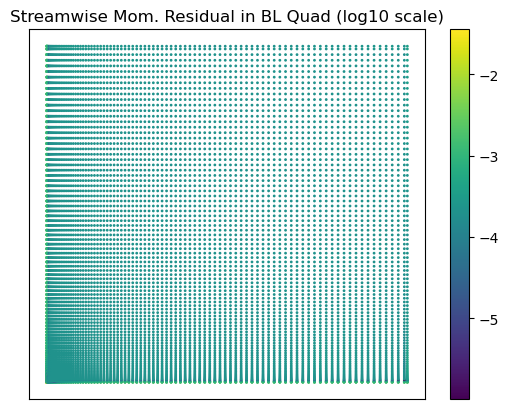

In [10]:
# Quick residual check
pg = 0.008666135084163201 # calculated in Aug25 notebook

plt.scatter(x_quad, y_quad, c = np.log10(np.abs(U_Wx + V_Wy + RST_xz + RST_yz - (nu_Wxx + nu_Wyy) - pg)), s=1)
plt.title('Streamwise Mom. Residual in BL Quad (log10 scale)')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

# Dominant Balance on the Quad

In [22]:
# Train Gaussian mixture model

# Advection, viscous, Reynolds stresses
features = np.vstack([(U_Wx).flatten(), (V_Wy).flatten(), (nu_Wxx).flatten(), (nu_Wyy).flatten(), (RST_xz).flatten(), (RST_yz).flatten()]).T
nfeatures = features.shape[1]
    
# Fit Gaussian mixture model
# nc = 3 # 3: freestream, wall, corners
nc = 7 # 2: freestream and wall... corner vortices will not be present in x-direction since we are loking strictly at momentum transport in the x-direction
seed = np.random.randint(2**32)
# seed = 3696299933  #  Keep a seed for debugging/plotting
print(seed)
model = GaussianMixture(n_components=nc, random_state=seed)

# PERMUTATION
sample_pct = 1
mask = np.random.permutation(features.shape[0])[:int(sample_pct*features.shape[0])]
model.fit(features[mask, :])

1701295068


GaussianMixture(n_components=7, random_state=1701295068)

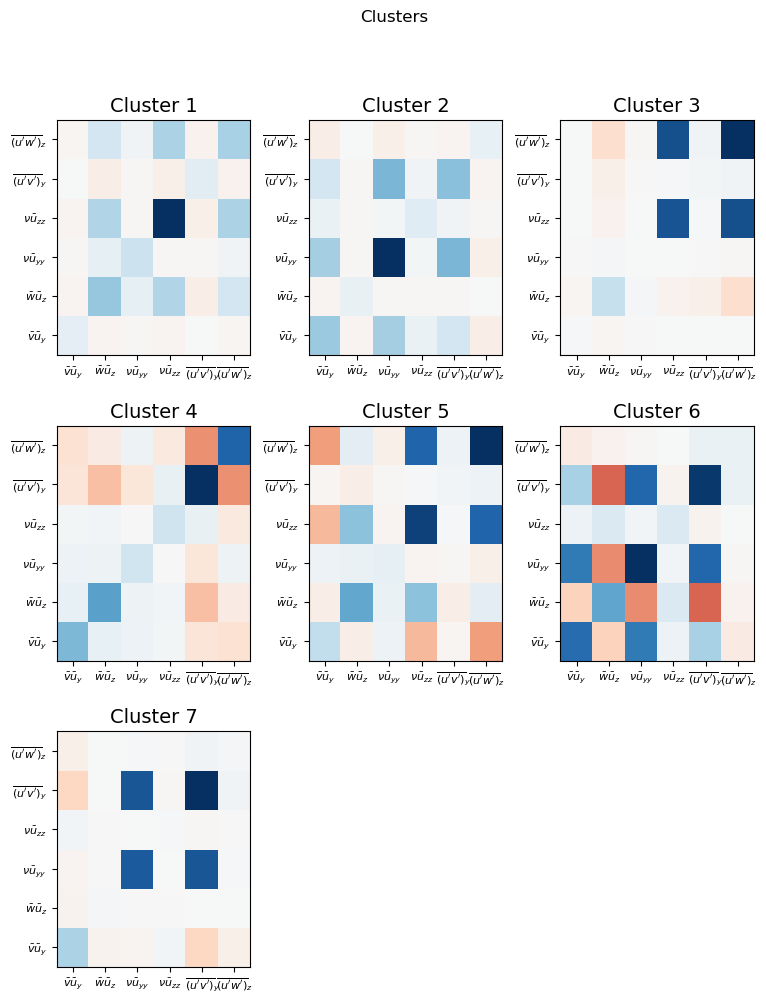

In [23]:
####################################
plt.figure(figsize=(9, 11))
for i in range(nc):
    plt.subplot(3, 3, i+1)
    C = model.covariances_[i, :, :]
    plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
    plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
    plt.gca().set_xticklabels(labels, fontsize=8)
    plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
    plt.gca().set_yticklabels(labels, fontsize=8)
    plt.gca().set_title('Cluster {0}'.format(i+1), fontsize=14)
    
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
plt.suptitle("Clusters")
plt.show()

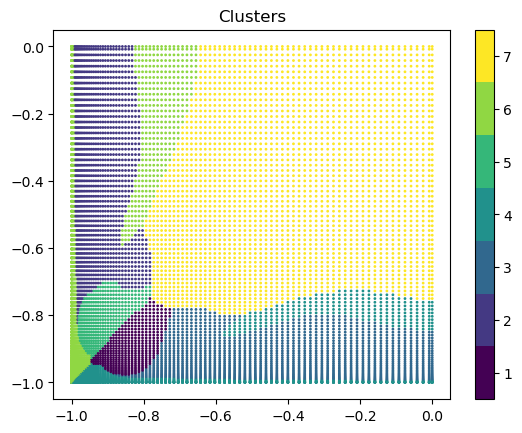

In [27]:
cluster_idx = model.predict(features)
clustermap = np.reshape(cluster_idx, x_quad.shape)

plt.scatter(x_quad, y_quad, c = clustermap+1, s=1)
plt.title(r'Clusters')
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))
plt.show()

Why is the flow attached to the wall the same as the freestream? Also 3&2 and 4&5 look very similar... but DB is finding some way of distinguishing the physics!

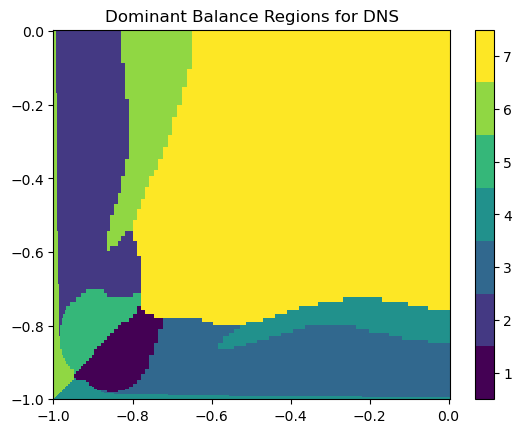

In [28]:
plt.pcolor(x_quad, y_quad, (clustermap+1))
plt.title('Dominant Balance Regions for DNS')
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))

In [181]:
# cluster_idx = np.load("cluster_idx.npy")
# np.save('cluster_idx.npy',cluster_idx)

In [29]:
def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [30]:
cluster_err = []
alphas = 1e-1*np.array([0.001,0.0025,0.005,0.01,0.0125,0.015,0.0175,0.02,0.0225,0.025,0.0325,0.0375,0.048,0.05,0.0625,0.075,0.08,0.0875,0.1,0.11,0.12,0.13,0.14,0.15,0.175,0.2,0.225,0.25,0.3,0.35,0.4,0.45,0.5,0.625,0.75,0.8,0.85,0.875,1,1.5,2.0,3.0,4.0,5.0,7.0,10.0,12.0,15.0,20.0,1000])

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx, i))

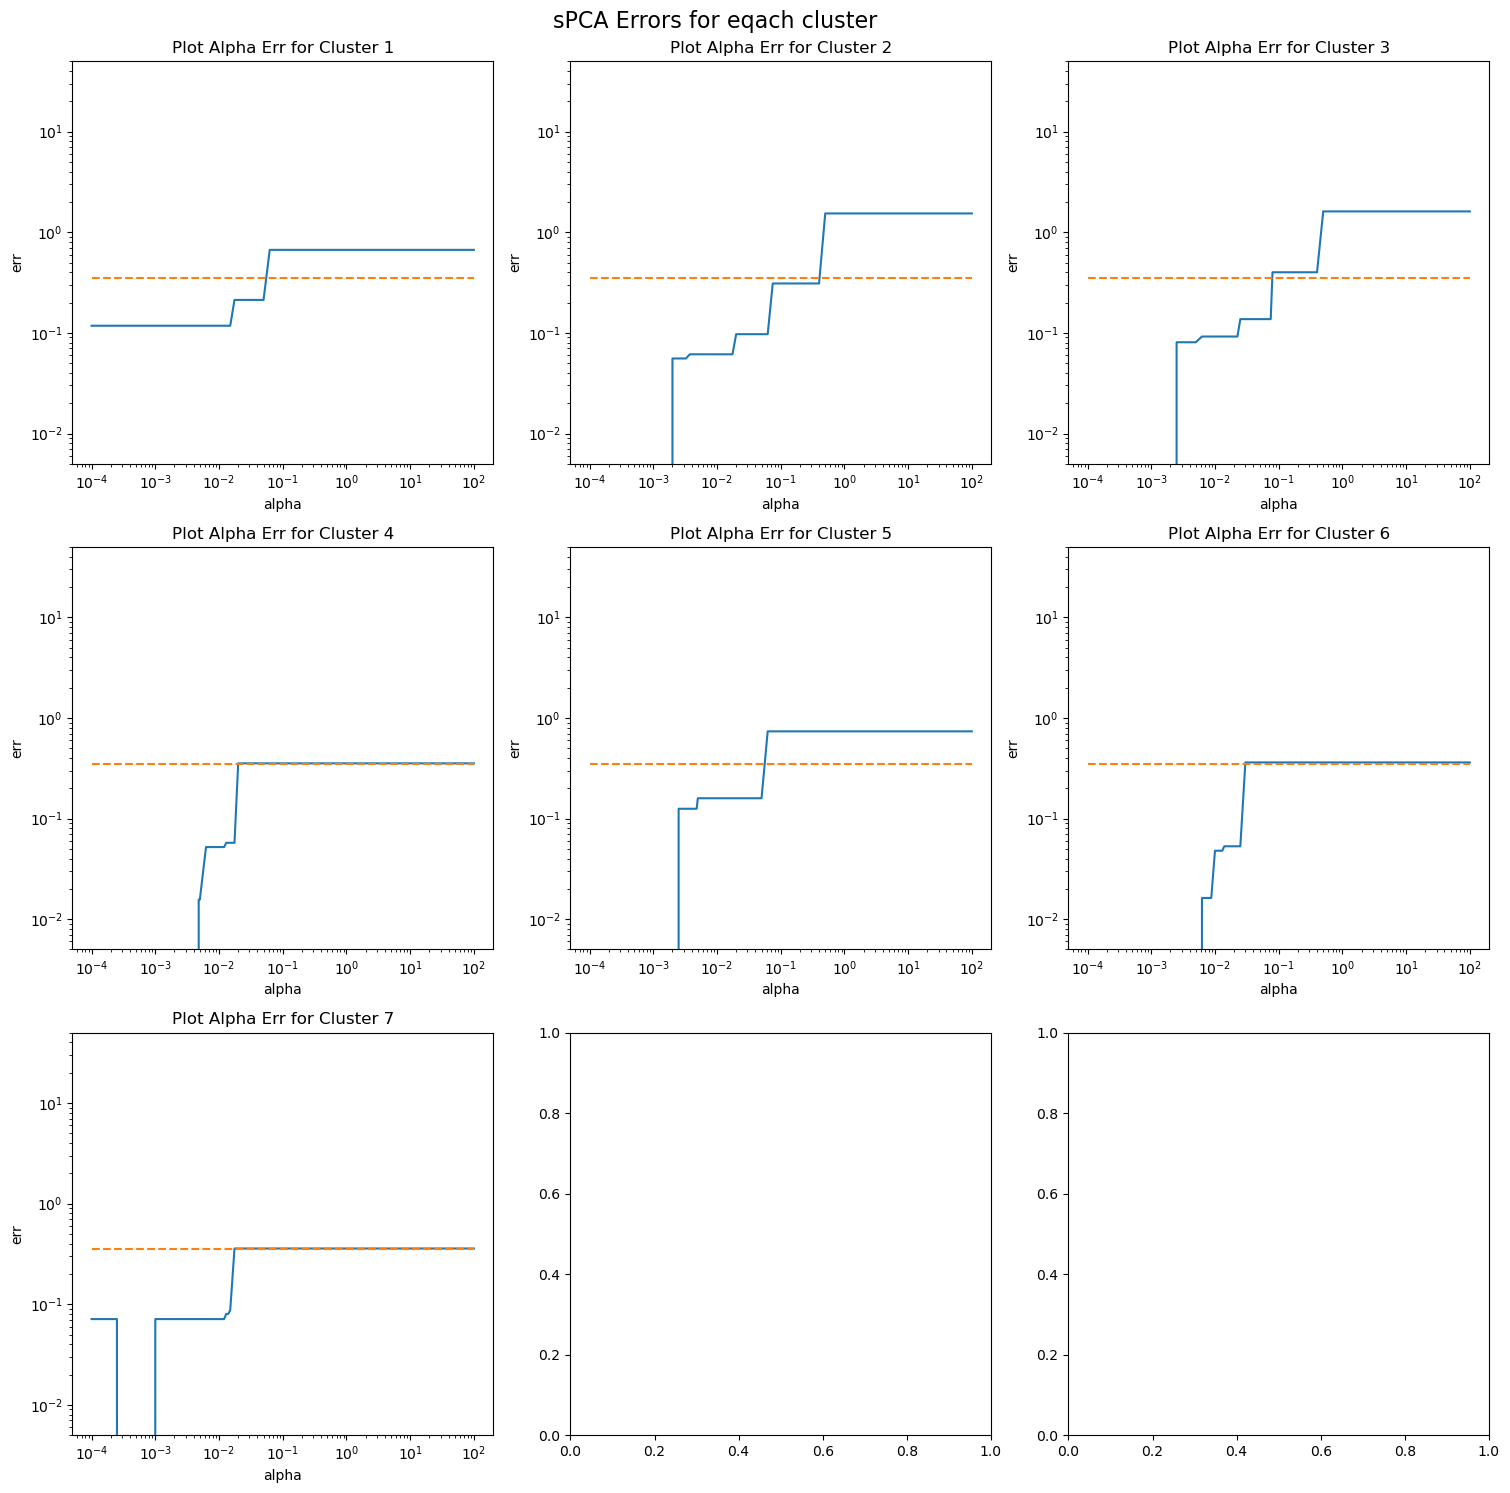

In [31]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    axes[i].loglog(alphas, 0.35 * np.ones_like(np.array(alphas)), linestyle='--')
    # if i == 2:
    #     axes[i].set_xlim(0.0625,0.0875)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')
    axes[i].set_ylim(5e-3,50)

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [32]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
            print(active_terms)
        else: print('None')

    return spca_model

In [33]:
# err_threshold = 28 maximum I can truncate before I loose viscous effect in the part over the the 
err_threshold = 0.35

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

print(alpha_opt)
optimal_alphas = alpha_opt

[0.05, 0.4, 0.07500000000000001, 0.017499999999999998, 0.05, 0.025, 0.015]


In [37]:
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten())

[0 1 3 5]
[2 4]
[1 3 5]
[1 3 5]
[0 1 2 4]
[0 2 4]
[1 4 5]


In [38]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten()])

# Make the colors nice, swap green & orange, than green & brown
model_index = np.where(model_index==1, 0, np.where(model_index == 0, 1, model_index))
balance_model_row_save = balance_models[1].copy()
balance_models[1] = balance_models[0]
balance_models[0] = balance_model_row_save

model_index = np.where(model_index==2, 5, np.where(model_index == 5, 2, model_index))
balance_model_row_save = balance_models[2].copy()
balance_models[2] = balance_models[5]
balance_models[5] = balance_model_row_save

model_index = np.where(model_index==2, 1, np.where(model_index == 1, 2, model_index))
balance_model_row_save = balance_models[2].copy()
balance_models[2] = balance_models[1]
balance_models[1] = balance_model_row_save

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten()])

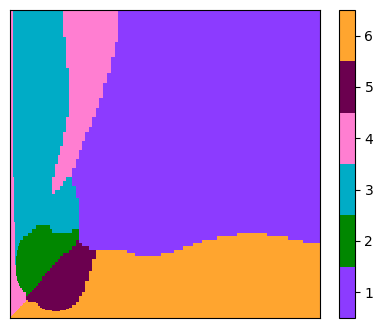

<Figure size 640x480 with 0 Axes>

In [39]:
plt.figure(figsize = (5.0,4.0))
plt.pcolormesh(x_quad,y_quad, (balance_idx+1).reshape(x_quad.shape), cmap = cm_balance_models, vmin=-0.5, vmax=cm.N-0.5)
plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
# plt.savefig(f'VortTran_sPCA_ClusterDomain,nc{nc}', transparent=True,dpi=480)
plt.show()
plt.clf()

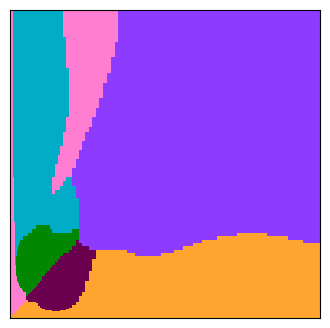

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure(figsize = (4.0,4.0))
plt.pcolormesh(x_quad,y_quad, (balance_idx+1).reshape(x_quad.shape), cmap = cm_balance_models, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(f'RANSDuct_sPCA_ClusterDomain,nc{nc}', transparent=True,dpi=720)
plt.show()
plt.clf()

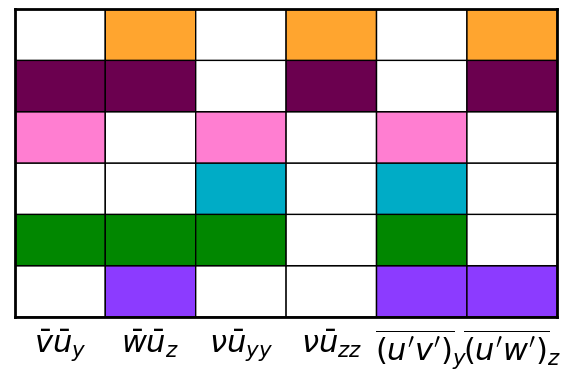

<Figure size 640x480 with 0 Axes>

In [324]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

# NOTE We're skipping the deleting of unidentified terms because I need to count terms correctly identified as 0 in my quantitative metric
# plot spca_model matrix
# Delete zero terms
# grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
# gridmap = np.delete(gridmap, grid_mask, axis=1)
# grid_labels = np.delete(labels, grid_mask)

grid_labels = labels

plt.figure(figsize=(7, 4))
plt.pcolor(gridmap, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels, fontsize=22)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.savefig(f'DuctRANS_sPCA_Matrix_Model', bbox_inches='tight',transparent=True, dpi=480)
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

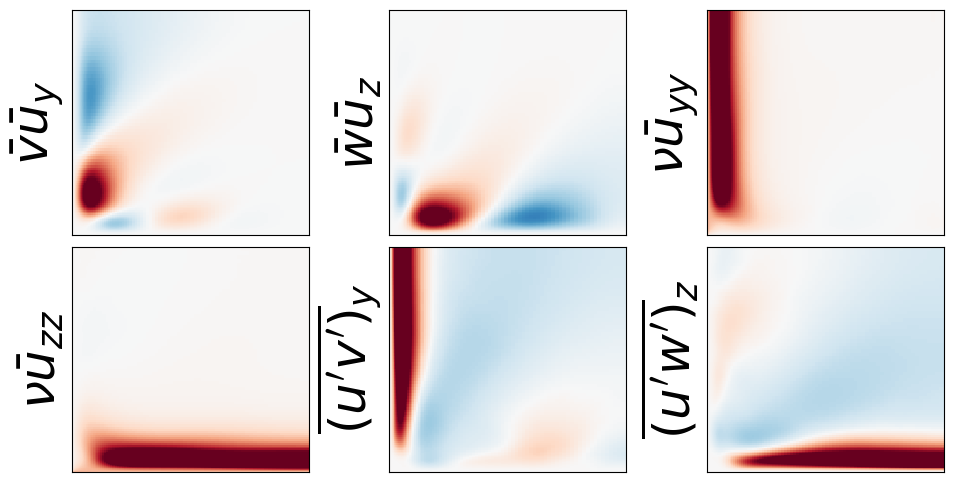

In [151]:
# Plot all six terms in the RANS equation
plt.figure(figsize=(11.25, 6))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
clim = 2.5e-2
fontsize=36

plt.subplot(231)
field = np.reshape(features[:,0], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
field = np.reshape(features[:,1], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
field = np.reshape(features[:,2], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(234)
field = np.reshape(features[:,3], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(235)
field = np.reshape(features[:,4], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(236)
field = np.reshape(features[:,5], x_quad.shape)
plt.pcolormesh(x_quad, y_quad, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[5], fontsize=fontsize)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.34, hspace=0.05)

plt.savefig('RANSDuct_Terms.png', transparent=True,dpi=720)#,bbox_inches='tight'

plt.show()

In [27]:
# np.save("cluster_idx.npy",cluster_idx)
# np.save("features.npy",features)